# NYC AnB room type classification 

**Goal** : Predict the ```room_type``` of an Airnb listing (Entire home/apt , Private room , or Shared room) using listing attributes such as price , location , availabality and review activity . 

**What will we cover** 

1. Problem framing & data loading 
2. Explorator data analysis (EDA) - Univariate , bivariate , skewness ourliers
3. Data cleaning & feature engineering
4. Train / test split
5. Preprocessing with ```ColumnTransformer``` + ```Pipeline``` 
6. Baseline Model 
7. Multiple candidate algoriths (Logistic Regression , Decision Tree , Random forest , Gradient Boosting )
8. Model comparison (Cross-validation)
9. Hyperparameter Tuning for the bese model 
10. Fianl evaluation on the untouched test set
11. Feature importance
12. Savinf the final pipeline ( model artifact)
13. Conclusion & Nest steps

## Import dependencies

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

In [2]:
df_v1 = pd.read_csv(r"D:\Robotics\Machine Learning Projects\House type prediction end-to-end project\data\AB_NYC_2019.csv")

In [3]:
df_v1.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Dataset successfully loaded to the notebook !!!

## Exploratory Data Analysis 
We explore the data in the standard order every ML engineer follows:

- Missing values
- Univariate analysis (one variable at a time — distributions, skewness)
- Bivariate analysis (relationship between features and the target)
- Correlation between numeric features
- Outlier inspection

In [4]:
print(f"""Shape of the data is {df_v1.shape}""")

Shape of the data is (48895, 16)


### Missing values

In [20]:
df_v1.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

It gave information related to all the columns , however there is a way if u want to see only the columns with missing values and that is , as follows

In [21]:
missing  = df_v1.isnull().sum()
missing[missing>0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

So Now if we look , it is easier to look at and find the columns with the missing values . We have only four columns with missing values . 

### Target - room_type

In [22]:
df_v1['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

Above we can observe that we have 3 different category for the target - room_type
1. Private room 
2. Entire home/apt
3. Shared room 

In [24]:
df_v1['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [5]:
df_v1.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
df_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
df_v1.duplicated().sum()

np.int64(0)

In [8]:
df_v1.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>],
       [<Axes: title={'center': 'availability_365'}>, <Axes: >, <Axes: >]],
      dtype=object)

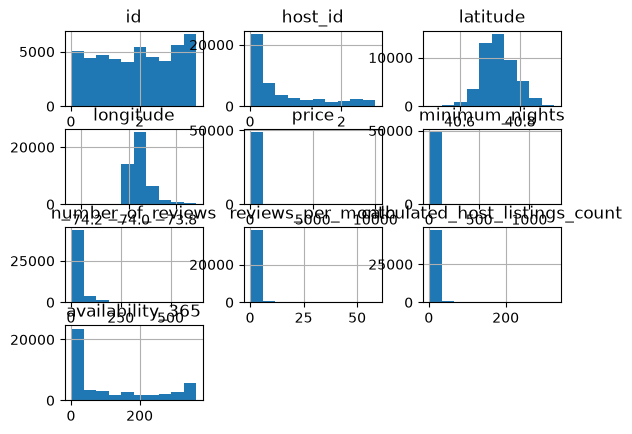

In [9]:
df_v1.hist()

In [10]:
df_v1.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [11]:
df_v1['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

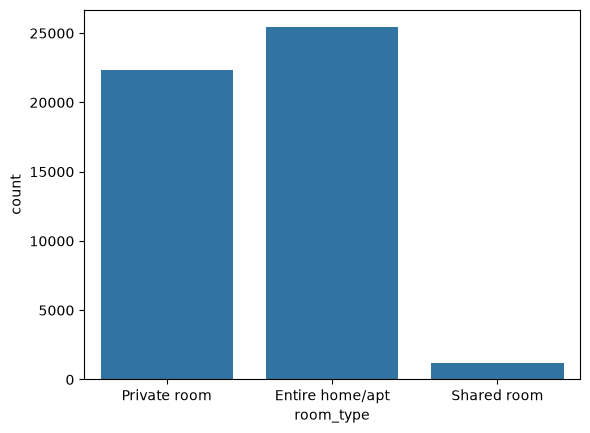

In [12]:
df_v1['room_type'].value_counts()
sns.countplot(x='room_type',data = df_v1)

The classes are imbalanced , shared room have small Minority . 


In this type of cases machine learning model bias on majority classes . Train better on majority and focus less on minority classes . 

### Univariate analysis : Numeric features


In [13]:
df_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [14]:
df_v1.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

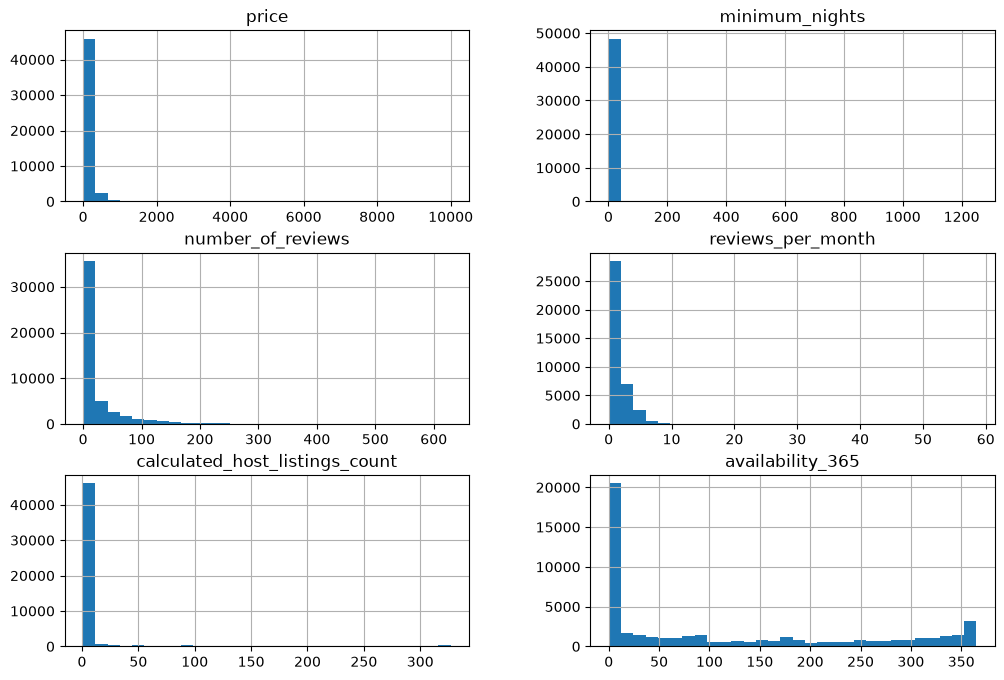

In [15]:
numeric_cols = ['price', 'minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
df_v1[numeric_cols].hist(bins=30,figsize=(12,8))

In [16]:
df_v1['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

<Axes: >

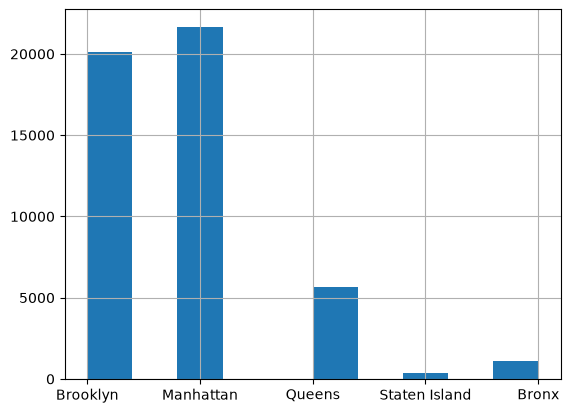

In [17]:
df_v1['neighbourhood_group'].hist()

<Axes: xlabel='neighbourhood_group', ylabel='count'>

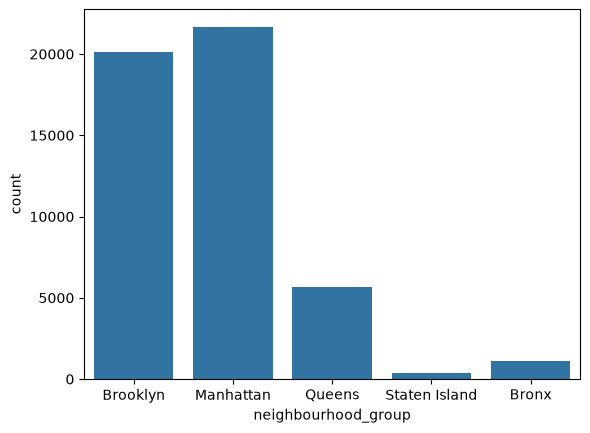

In [18]:
sns.countplot(data=df_v1 , x='neighbourhood_group')

### Bivariate Analysis - Features vs Target

<Axes: xlabel='room_type', ylabel='price'>

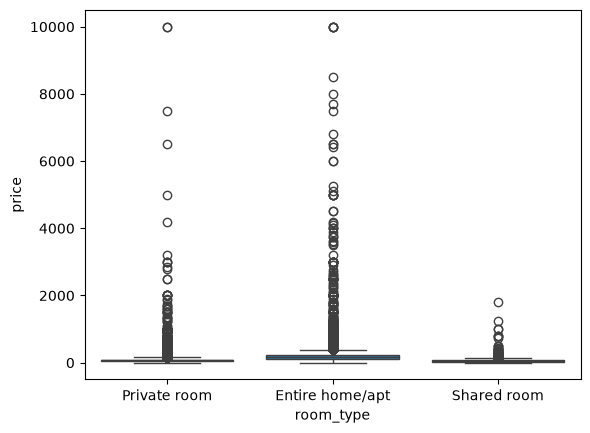

In [19]:
sns.boxplot(x='room_type',y='price' , data= df_v1)

### **Correlation between numeric feature**